In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
sns.set_theme(style="darkgrid")

print("✅ Libraries loaded")

✅ Libraries loaded


In [4]:
df = pd.read_csv(
    '../data/household_power_consumption.txt',
    sep=';',
    na_values=['?'],
    low_memory=False
)

# Combine Date and Time into a single datetime column manually
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)

# Drop original Date and Time columns
df.drop(columns=['Date', 'Time'], inplace=True)

# Set datetime as index
df.set_index('datetime', inplace=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
df.head()

Shape: (2075259, 7)
Date range: 2006-12-16 17:24:00 → 2010-11-26 21:02:00


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [5]:
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

print(f"\nTotal missing: {df.isnull().sum().sum():,} values")
print(f"Total rows: {len(df):,}")

=== DATA TYPES ===
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

=== MISSING VALUES ===
                       Missing Count  Missing %
Global_active_power            25979   1.251844
Global_reactive_power          25979   1.251844
Voltage                        25979   1.251844
Global_intensity               25979   1.251844
Sub_metering_1                 25979   1.251844
Sub_metering_2                 25979   1.251844
Sub_metering_3                 25979   1.251844

Total missing: 181,853 values
Total rows: 2,075,259


In [6]:
# Convert all columns to numeric (safety step)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing values using forward fill then backward fill
df.ffill(inplace=True)
df.bfill(inplace=True)

print(f"✅ Missing values after fix: {df.isnull().sum().sum()}")
print(f"Shape after cleaning: {df.shape}")

✅ Missing values after fix: 0
Shape after cleaning: (2075259, 7)


In [7]:
# Resample from per-minute to per-hour (mean)
df_hourly = df.resample('h').mean()

print(f"Hourly dataset shape: {df_hourly.shape}")
print(f"Date range: {df_hourly.index.min()} → {df_hourly.index.max()}")
df_hourly.head()

Hourly dataset shape: (34589, 7)
Date range: 2006-12-16 17:00:00 → 2010-11-26 21:00:00


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


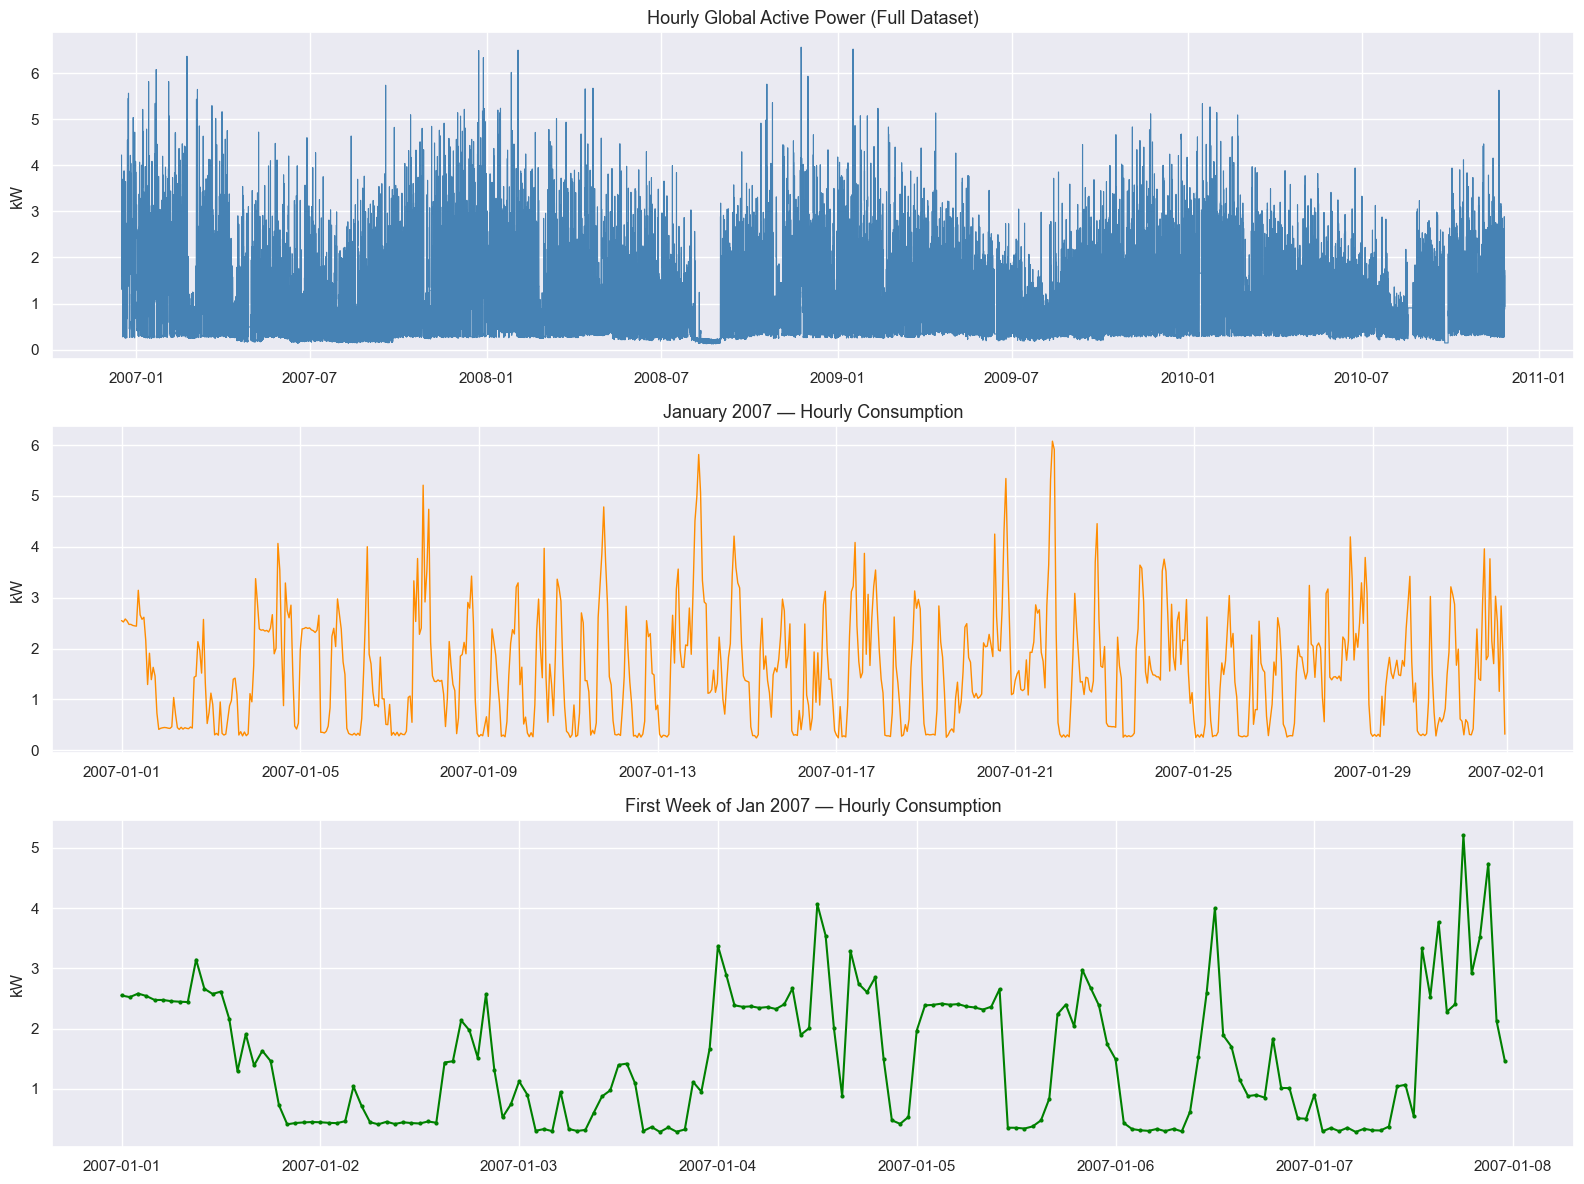

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Full timeline
axes[0].plot(df_hourly['Global_active_power'], color='steelblue', linewidth=0.8)
axes[0].set_title('Hourly Global Active Power (Full Dataset)', fontsize=13)
axes[0].set_ylabel('kW')

# Zoom into 1 month
one_month = df_hourly.loc['2007-01']
axes[1].plot(one_month['Global_active_power'], color='darkorange', linewidth=1)
axes[1].set_title('January 2007 — Hourly Consumption', fontsize=13)
axes[1].set_ylabel('kW')

# Zoom into 1 week
one_week = df_hourly.loc['2007-01-01':'2007-01-07']
axes[2].plot(one_week['Global_active_power'], color='green', linewidth=1.5, marker='o', markersize=2)
axes[2].set_title('First Week of Jan 2007 — Hourly Consumption', fontsize=13)
axes[2].set_ylabel('kW')

plt.tight_layout()
plt.savefig('../data/plot_raw_power.png', dpi=150)
plt.show()

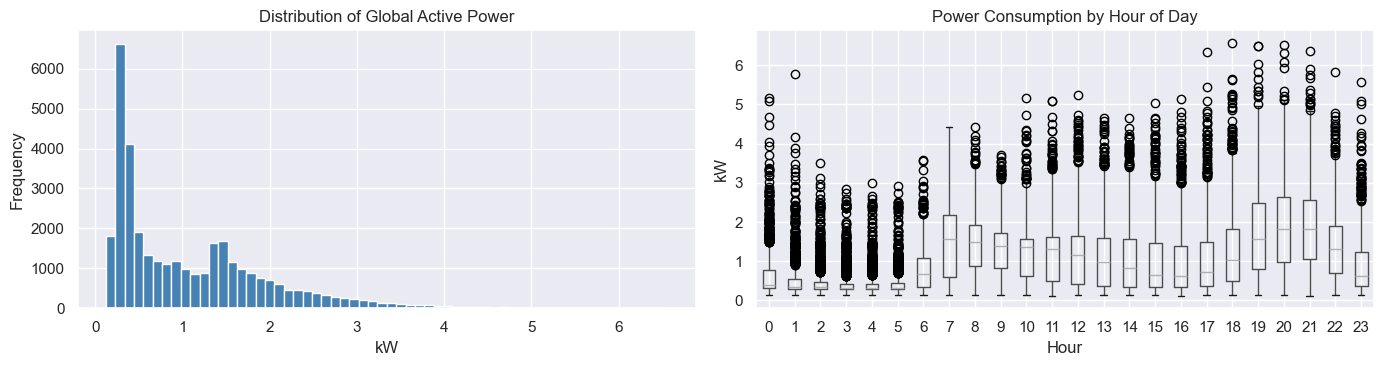

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(df_hourly['Global_active_power'].dropna(), bins=60, 
             color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Global Active Power')
axes[0].set_xlabel('kW')
axes[0].set_ylabel('Frequency')

# Box plot by hour of day
df_hourly['hour'] = df_hourly.index.hour
df_hourly.boxplot(column='Global_active_power', by='hour', ax=axes[1])
axes[1].set_title('Power Consumption by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('kW')

plt.suptitle('')
plt.tight_layout()
plt.show()

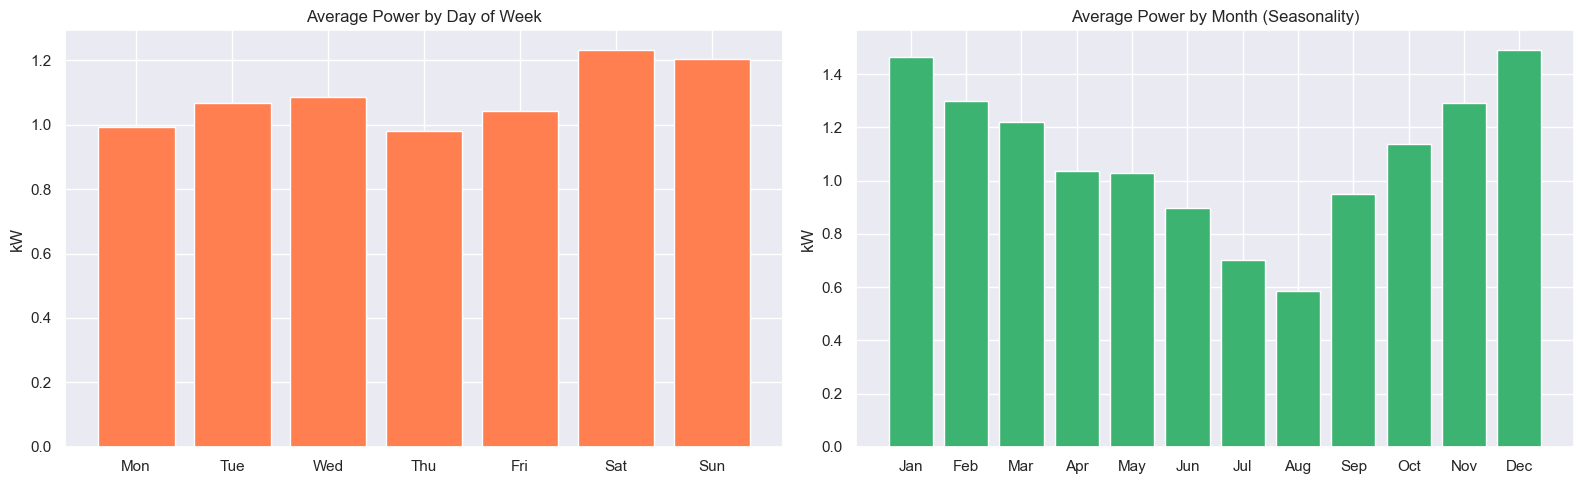

In [13]:
df_hourly['day_of_week'] = df_hourly.index.dayofweek   # 0=Mon, 6=Sun
df_hourly['month'] = df_hourly.index.month

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Average by day of week
dow_avg = df_hourly.groupby('day_of_week')['Global_active_power'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[0].bar(days, dow_avg.values, color='coral', edgecolor='white')
axes[0].set_title('Average Power by Day of Week')
axes[0].set_ylabel('kW')

# Average by month
month_avg = df_hourly.groupby('month')['Global_active_power'].mean()
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar(months, month_avg.values, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Average Power by Month (Seasonality)')
axes[1].set_ylabel('kW')

plt.tight_layout()
plt.show()

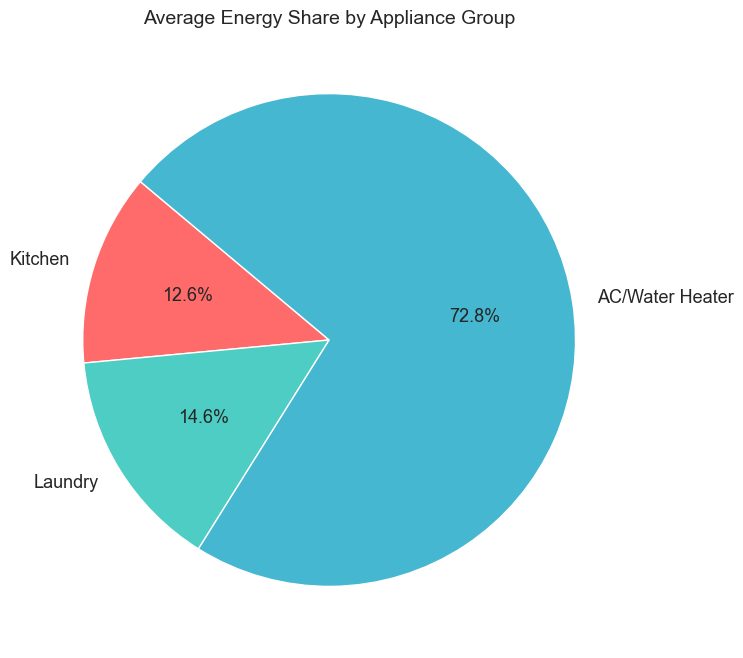

In [14]:
# Average contribution of each sub-meter
sub_cols = ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
sub_means = df_hourly[sub_cols].mean()

labels = ['Kitchen', 'Laundry', 'AC/Water Heater']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

plt.figure(figsize=(8, 8))
plt.pie(sub_means, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=140, textprops={'fontsize': 13})
plt.title('Average Energy Share by Appliance Group', fontsize=14)
plt.show()

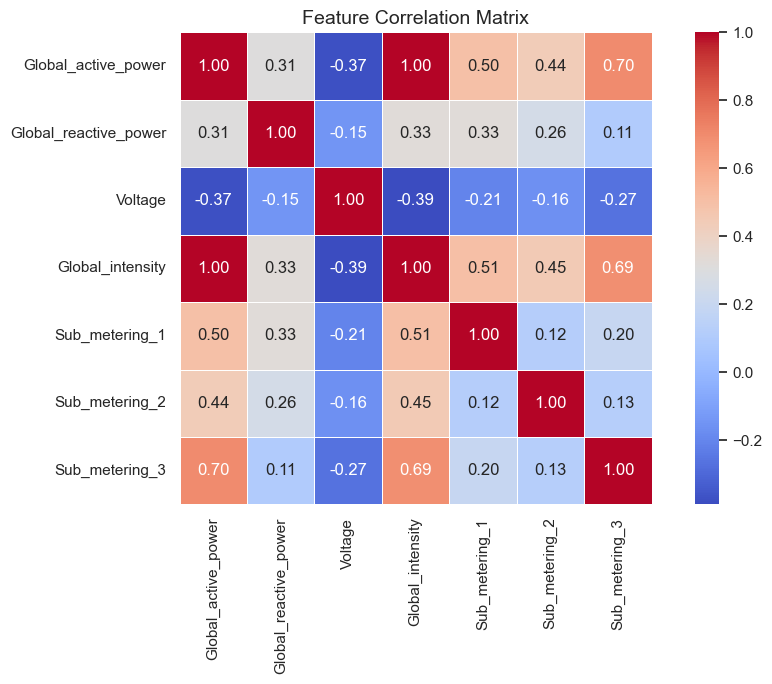

In [15]:
plt.figure(figsize=(10, 7))
corr = df_hourly[['Global_active_power', 'Global_reactive_power',
                   'Voltage', 'Global_intensity',
                   'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
# Drop temporary columns before saving
df_hourly.drop(columns=['hour', 'day_of_week', 'month'], inplace=True)

# Save cleaned hourly dataset
df_hourly.to_csv('../data/cleaned_hourly.csv')

print(f"✅ Saved cleaned_hourly.csv")
print(f"Shape: {df_hourly.shape}")
print(f"Columns: {list(df_hourly.columns)}")
print(f"Date range: {df_hourly.index.min()} → {df_hourly.index.max()}")

✅ Saved cleaned_hourly.csv
Shape: (34589, 7)
Columns: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
Date range: 2006-12-16 17:00:00 → 2010-11-26 21:00:00
